# Biến đổi ảnh bằng Local Binary Patterns (LBP)

Mounted at /content/drive
Tìm thấy 1 ảnh:
01. anh1.jpg

[1/1] Đang xử lý: anh1.jpg
Kích thước ảnh màu: (789, 719, 3)
Kích thước ảnh xám: (789, 719)


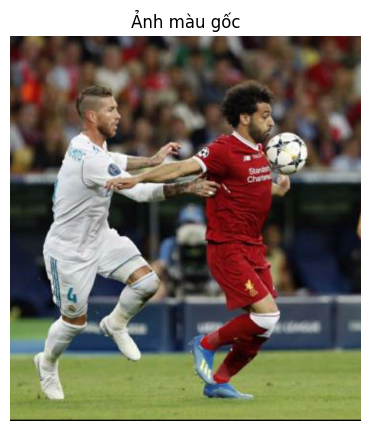

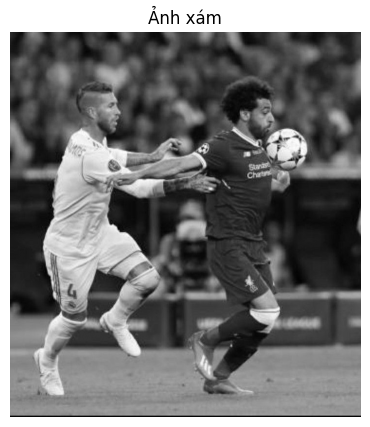

Đang tính LBP với P=8, R=1...


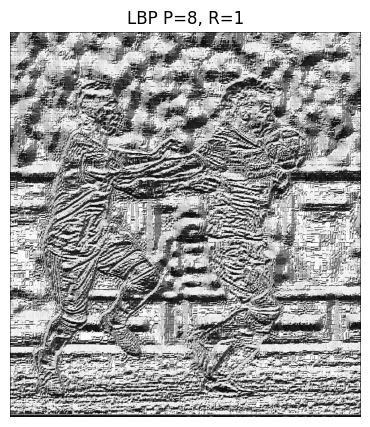

Đang tính LBP với P=8, R=2...


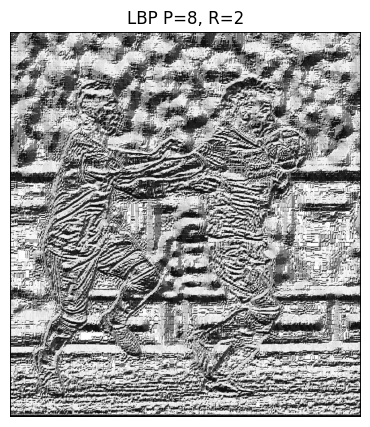

Đang tính LBP với P=16, R=2...


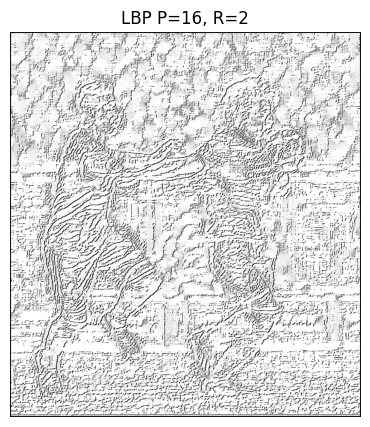

Đang tính LBP với P=16, R=3...


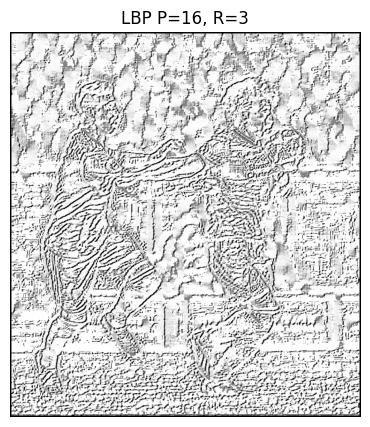

Đang tính LBP với P=24, R=3...


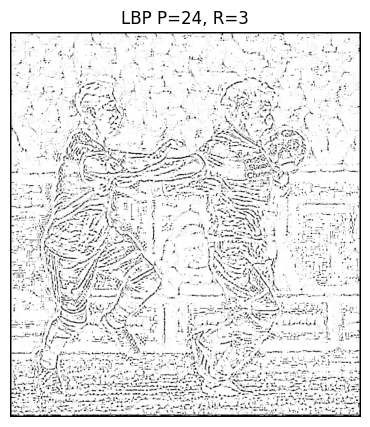


Đã xử lý xong toàn bộ 1 ảnh.


In [1]:
# =========================================================
# BƯỚC 1: IMPORT THƯ VIỆN
# =========================================================
import math
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive


# =========================================================
# BƯỚC 2: KẾT NỐI GOOGLE DRIVE
# =========================================================
drive.mount("/content/drive")


# =========================================================
# BƯỚC 3: KHAI BÁO CẤU HÌNH
# =========================================================
INPUT_DIR = Path(
    "/content/drive/MyDrive/DataAnalyst"
)

# None: giữ nguyên kích thước ảnh.
# Ví dụ: 500 để cạnh dài nhất tối đa 500 pixel.
RESIZE_MAX_SIDE = None

# None: xử lý toàn bộ ảnh.
# Ví dụ: 3 để xử lý 3 ảnh đầu tiên.
MAX_IMAGES = 1

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

LBP_CONFIGURATIONS = [
    {"P": 8,  "R": 1},
    {"P": 8,  "R": 2},
    {"P": 16, "R": 2},
    {"P": 16, "R": 3},
    {"P": 24, "R": 3},
]


# =========================================================
# BƯỚC 4: LẤY TOÀN BỘ ẢNH TRONG THƯ MỤC
# =========================================================
if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục: {INPUT_DIR}"
    )

image_paths = sorted(
    path
    for path in INPUT_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in SUPPORTED_EXTENSIONS
)

if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

if not image_paths:
    raise FileNotFoundError(
        f"Không tìm thấy ảnh trong: {INPUT_DIR}"
    )

print(f"Tìm thấy {len(image_paths)} ảnh:")

for index, image_path in enumerate(
    image_paths,
    start=1
):
    print(f"{index:02d}. {image_path.name}")


# =========================================================
# BƯỚC 5: DUYỆT VÀ XỬ LÝ TỪNG ẢNH
# =========================================================
for image_index, image_path in enumerate(
    image_paths,
    start=1
):
    print(
        f"\n[{image_index}/{len(image_paths)}] "
        f"Đang xử lý: {image_path.name}"
    )

    # -----------------------------------------------------
    # 5.1. ĐỌC ẢNH MÀU
    # -----------------------------------------------------
    raw_data = np.fromfile(
        str(image_path),
        dtype=np.uint8
    )

    image_bgr = cv2.imdecode(
        raw_data,
        cv2.IMREAD_COLOR
    )

    if image_bgr is None:
        print(
            f"Không thể đọc ảnh: {image_path.name}"
        )
        continue

    # -----------------------------------------------------
    # 5.2. CHUYỂN ẢNH MÀU SANG ẢNH XÁM
    # -----------------------------------------------------
    gray_image = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2GRAY
    )

    print(
        "Kích thước ảnh màu:",
        image_bgr.shape
    )

    print(
        "Kích thước ảnh xám:",
        gray_image.shape
    )


    # -----------------------------------------------------
    # 5.3. HIỂN THỊ ẢNH MÀU GỐC
    # -----------------------------------------------------
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(image_rgb)
    plt.title(
        f"Ảnh màu gốc"
    )
    plt.axis("off")
    plt.show()


    # -----------------------------------------------------
    # 5.5. HIỂN THỊ ẢNH XÁM
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.imshow(
        gray_image,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    plt.title(
        f"Ảnh xám"
    )
    plt.axis("off")
    plt.show()


    # =====================================================
    # BƯỚC 6: CHẠY TỪNG CẤU HÌNH LBP
    # =====================================================
    for config in LBP_CONFIGURATIONS:
        P = config["P"]
        R = config["R"]

        print(
            f"Đang tính LBP với P={P}, R={R}..."
        )

        height, width = gray_image.shape

        # Ảnh chứa kết quả LBP cuối.
        lbp_result = np.zeros(
            (height, width),
            dtype=np.uint8
        )

        # P=8  → 1 phần 8 bit.
        # P=16 → 2 phần 8 bit.
        # P=24 → 3 phần 8 bit.
        number_of_parts = P // 8

        byte_parts = np.zeros(
            (number_of_parts, height, width),
            dtype=np.uint8
        )

        # Không xử lý các pixel ở vùng biên.
        margin = math.ceil(R)


        # -------------------------------------------------
        # 6.1. DUYỆT TỪNG PIXEL TRUNG TÂM
        # -------------------------------------------------
        for center_y in range(
            margin,
            height - margin
        ):
            for center_x in range(
                margin,
                width - margin
            ):
                center_value = gray_image[
                    center_y,
                    center_x
                ]

                bits = []


                # -----------------------------------------
                # 6.2. XÉT P ĐIỂM LÂN CẬN
                # -----------------------------------------
                for p in range(P):
                    angle = (
                        2 * math.pi * p / P
                    )

                    neighbor_x = round(
                        center_x
                        + R * math.cos(angle)
                    )

                    neighbor_y = round(
                        center_y
                        - R * math.sin(angle)
                    )

                    neighbor_value = gray_image[
                        neighbor_y,
                        neighbor_x
                    ]

                    if neighbor_value >= center_value:
                        bits.append(1)
                    else:
                        bits.append(0)


                # -----------------------------------------
                # 6.3. CHIA CHUỖI THÀNH CÁC NHÓM 8 BIT
                # -----------------------------------------
                part_values = []

                for i in range(0, P, 8):
                    eight_bits = bits[i:i + 8]

                    # Đổi 8 bit thành số thập phân
                    value = 0

                    for j in range(8):
                        value += eight_bits[j] * (2 ** j)

                    part_values.append(value)

                    # Lưu kết quả của từng nhóm 8 bit
                    part_index = i // 8

                    byte_parts[
                        part_index,
                        center_y,
                        center_x
                    ] = value


                # -----------------------------------------
                # 6.4. LẤY PHẦN CÓ GIÁ TRỊ LỚN NHẤT
                # -----------------------------------------
                lbp_result[
                    center_y,
                    center_x
                ] = max(part_values)


        # =================================================
        # BƯỚC 7: HIỂN THỊ KẾT QUẢ LBP
        # =================================================
        plt.figure(figsize=(8, 5))
        plt.imshow(
            lbp_result,
            cmap="gray",
            vmin=0,
            vmax=255
        )
        plt.title(
            f"LBP P={P}, R={R}"
        )
        plt.axis("off")
        plt.show()


print(
    f"\nĐã xử lý xong toàn bộ "
    f"{len(image_paths)} ảnh."
)